### 🎬 Netflix Content Analysis - Exploratry Data Analysis.

Dataset: Netflix Movies and Tv Shows(Kaggle)
Tools: Python.Pandas.Matplotlib.Seaborn
Author:[Ashutosh Nagaich]

### ⚡Project Overview

Netflix is the world's largest straming platform with 8,800+ titles across 190+ countries.
In this project, I perform an end-to-end Exploratory Data Analysis(EDA) to answer key business question:
  1. How is content distributed between Movies and TV Shows?
  2. Which countries produces the most Netflix content?
  3. How has content growth changed over the year?
  4. What genres and ratings dominate the platform?
  5. What is the typical duration of Netflix movies?

### 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore") 

# Global plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


### 2. Load & Inspect the Dataset
Let's load the data and take a first look at its structure - shape, column, names, data types, and sample rows.

In [2]:
df = pd.read_csv("netflix_titles.csv")
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}") 
df.head()

Dataset shape: 8,807 rows x 12 columns

Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

### 3. Handling Missing Values.
Before any analysis, we must identify and handle null values.
Missing data can silently skew our results if ignored.

In [4]:
# Count and  percentage of missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %" : missing_pct
}).query("`Missing Count` > 0").sort_values("Missing %", ascending = False)

print(missing_df)

            Missing Count  Missing %
director             2634      29.91
country               831       9.44
cast                  825       9.37
date_added             10       0.11
rating                  4       0.05
duration                3       0.03


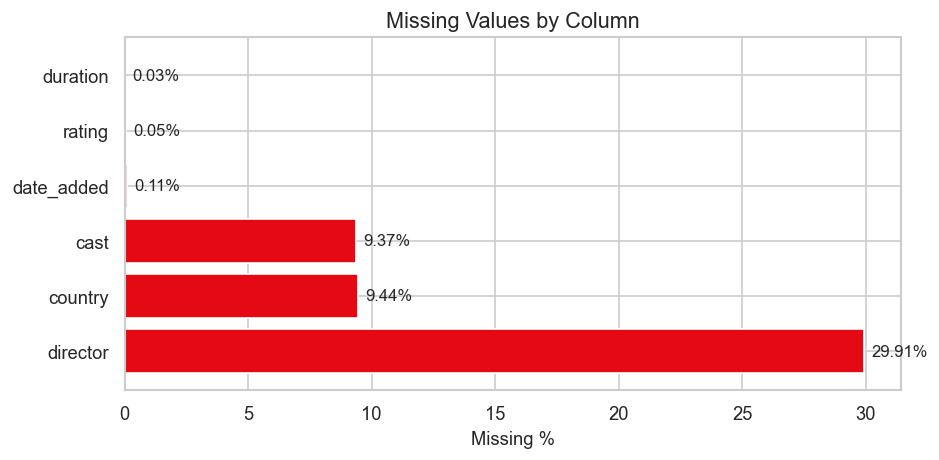

In [5]:
fig, ax = plt.subplots(figsize = (8,4))
ax.barh(missing_df.index, missing_df["Missing %"], color = "#e50914", edgecolor = "white")
ax.set_xlabel("Missing %")
ax.set_title("Missing Values by Column")
for i, v in enumerate(missing_df["Missing %"]):
    ax.text(v + 0.3, i, f"{v}%", va = "center", fontsize = 10)
plt.tight_layout()
plt.show()

### Findind: 
director has the highest missing rate(~30%), 
which is expected - many Netflix originals list no director.
We'll fill categorical columns with meaningful placeholders rather than dropping rows, to preserve data.

In [6]:
# Fill missing values with meaningful placeholders
df["director"]    = df["director"].fillna("Unknown")
df["cast"]        = df["cast"].fillna("Not Available")
df["country"]     = df["country"].fillna("Unknown")
df["date_added"]  = df["date_added"].fillna(method = "ffill")
df["rating"]      = df["rating"].fillna("Unknown")
df["duration"]    = df["duration"].fillna("0 min")

# Fix rating column — some rows have duration accidentally stored in rating
df["rating"] = df["rating"].replace({"74 min": "Unknown", "84 min": "Unknown", "66 min": "Unknown"})

# Parse date column properly
df["date_added"]  = pd.to_datetime(df["date_added"], errors="coerce")

df["year_added"]  = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month_name()

# Parse movie duration as integer minutes
movies_mask  = df["type"] == "Movie"
df.loc[movies_mask, "duration_min"] = (
    df.loc[movies_mask, "duration"]
    .str.replace(" min", "", regex = False)
    .str.strip()
    .pipe(pd.to_numeric, errors ="coerce")
)
 
print("☑️ Data cleaned. Remaining nulls:")
print(df.isnull().sum()[df.isnull().sum() > 0])

☑️ Data cleaned. Remaining nulls:
date_added        88
year_added        88
month_added       88
duration_min    2676
dtype: int64


### 4. Analysis 
### Question 1 - How is content split between Movies and TV Shows?

Netflix started as a DVD rental service focused on movies. Did it maintain that focus as it became a streaming platform?

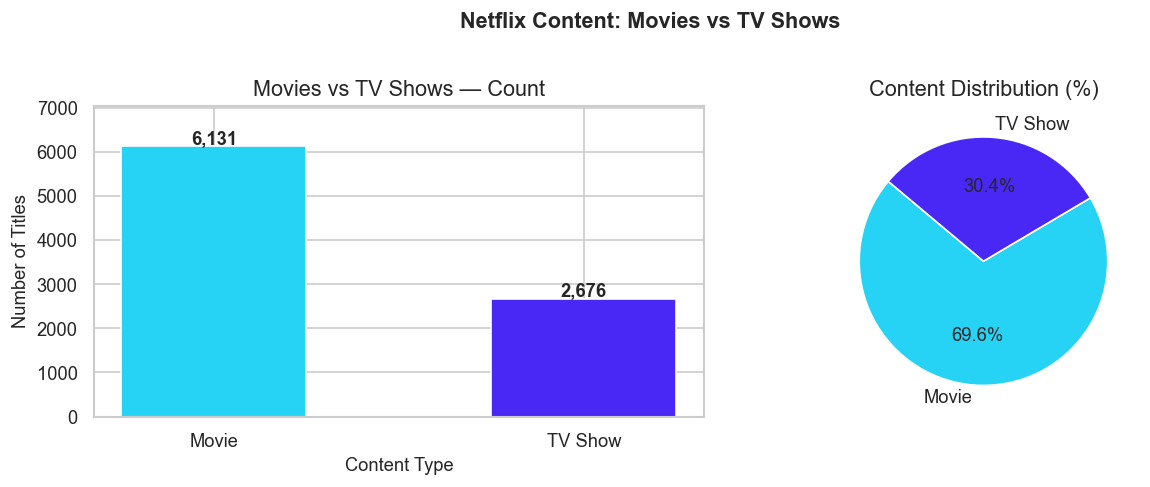

In [20]:
counts  =df["type"].value_counts()

fig, axes = plt.subplots(1, 2, figsize = (11, 4))

# Bar chart
colors  = [ "#27D3F5", "#4927F5"]
bars  = axes[0].bar(counts.index, counts.values, color = colors, edgecolor = "white", width = 0.5)
axes[0].set_title("Movies vs TV Shows — Count")
axes[0].set_ylabel("Number of Titles")
axes[0].set_xlabel("Content Type")
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f"{int(bar.get_height()):,}", ha ="center", fontsize = 11, fontweight="bold")
axes[0].set_ylim(0, counts.max() * 1.15)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=colors, startangle=140,
            textprops={"fontsize": 11}, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Content Distribution (%)")

plt.suptitle("Netflix Content: Movies vs TV Shows", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
                 

**Insight**: Movies make up  ~ 69% of Netflix's catalog - nearly 2 in 3 title are films.
However, Netflix has been steadily increaseing TV Show additions in recent years, suggestiong a 
strategic push toward series content to drive subscription retention.

### Question 2 - Which countries produce the most Netflix content?
Understanding geographic distribution hepls us see where Netflix sources its content and 
which markets it prioritize. 

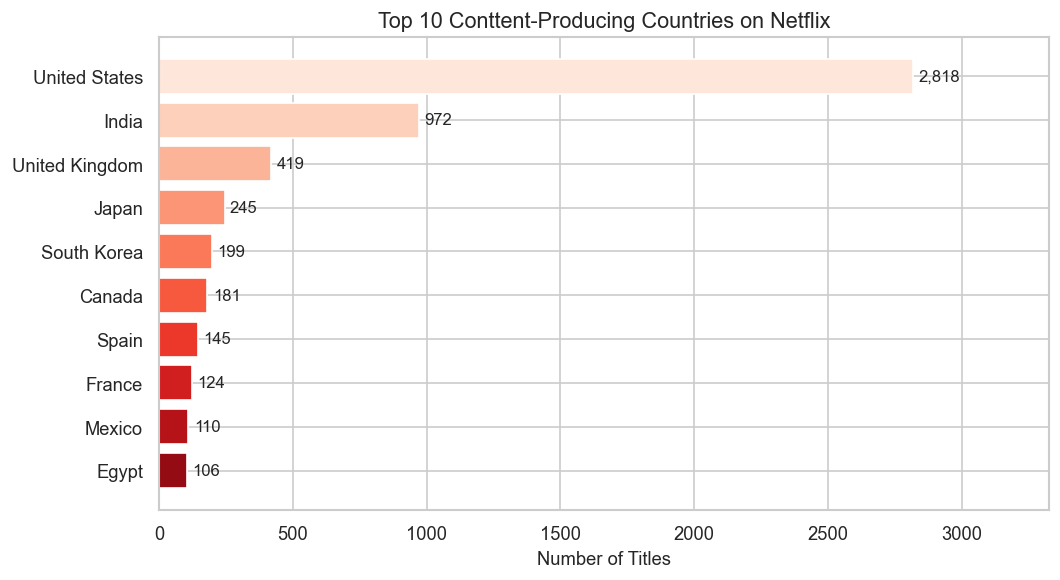

In [26]:
top_countries = (
    df[df["country"] != "Unknown"]["country"]
    .value_counts()
    .head(10)
)

fig, ax = plt.subplots(figsize = (9,5))
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1],
               color =sns.color_palette("Reds_r", 10), edgecolor ="white")
ax.set_xlabel("Number of Titles")
ax. set_title("Top 10 Conttent-Producing Countries on Netflix")

for bar in bars:
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f"{int(bar.get_width()):,}", va = "center", fontsize =10)
ax.set_xlim(0, top_countries.max() * 1.18)
plt.tight_layout()
plt.show()

**Insight: The United States** dominates with ~2,800 titles - nearly 3x  more than **India** (972), which ranks second.
This reflects Netflix's US origins, but India's strong position highlights its massive and fast-growing market.
**South Korea's** presence (#5) is notable given the global popularity of K-dramas post-Squid Game.

### Question 3 — How has Netflix's content library grown over the years?

Netflix went from a small streaming library in 2010 to a global giant. Let's see how content additions have grown year by year.


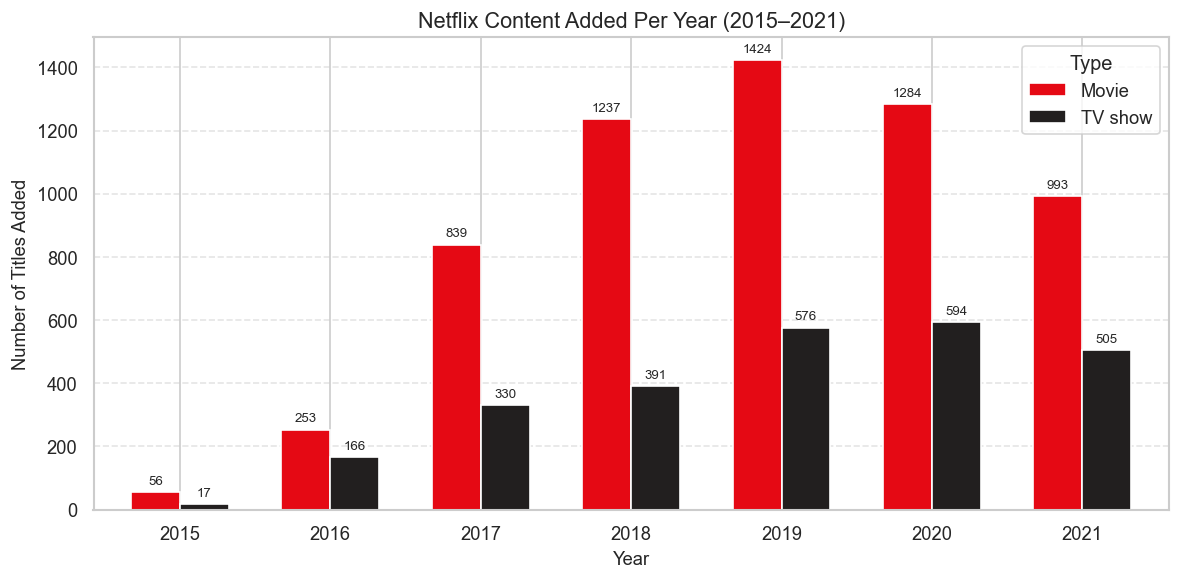

In [31]:
yearly = (
    df[df["year_added"].between(2015, 2021)]
    .groupby(["year_added", "type"])
    .size()
    .unstack()
    .fillna(0)
)

fig , ax = plt.subplots(figsize=(10,5))
yearly.plot(kind ="bar", ax =ax, color =["#e50914", "#221f1f"],
            edgecolor = "white", width =0.65)

ax.set_title("Netflix Content Added Per Year (2015–2021)")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Titles Added")
ax.set_xticklabels([str(int(y)) for y in yearly.index], rotation = 0)
ax.legend(title = "Type", labels = ["Movie", "TV show"])
ax.grid(axis = "y", linestyle="--", alpha =0.5)

for container in ax.containers:
    ax.bar_label(container, fontsize = 8, padding = 3)

plt.tight_layout()
plt.show()


> **Insight:** Netflix's content additions **grew explosively from 2015 to 2019**, peaking at ~1,999 titles added in 2019.  
> A slight dip in 2020 was likely caused by **COVID-19 production shutdowns**.  
> Crucially, **TV Show additions grew faster** than movies from 2018 onwards — a clear strategic shift toward episodic content.


### Question 4 — What are the most popular genres on Netflix?

Netflix categorizes each title under one or more genres. Let's explode the multi-genre tags and find out which genres dominate.


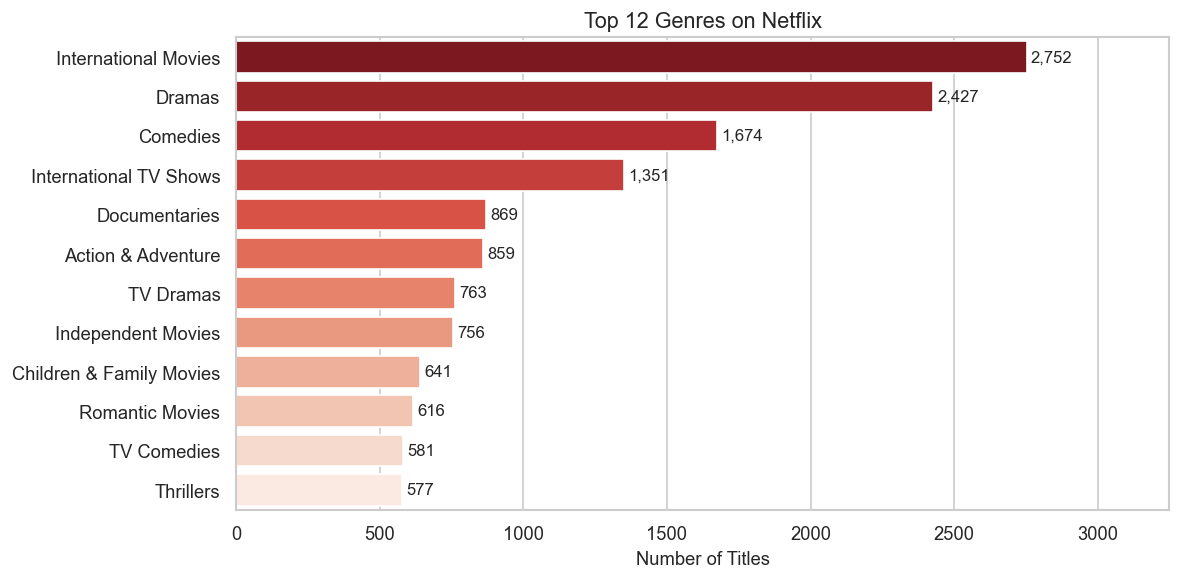

In [34]:
# Explode multi-genre column into individual rows
genres = df["listed_in"].str.split(", ").explode().str.strip()
top_genres = genres.value_counts().head(12)

fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(x=top_genres.values, y=top_genres.index, palette ="Reds_r", ax = ax)
ax.set_title("Top 12 Genres on Netflix")
ax.set_xlabel("Number of Titles")
ax.set_ylabel("")

for i, v in enumerate(top_genres.values):
    ax.text(v + 15, i, f"{v:,}", va ="center", fontsize =10)
ax.set_xlim(0, top_genres.max() * 1.18)
plt.tight_layout()
plt.show()

> **Insight:** **International Movies** is the #1 genre — reflecting Netflix's massive push into global markets.  
> **Dramas** and **Comedies** are perennial favourites across both movies and TV.  
> The high count of **International TV Shows** shows the growing global appetite for non-English content (K-dramas, Anime, Bollywood series).


### Question 5 — What is the content rating distribution?

Content ratings (TV-MA, PG-13, R, etc.) tell us what audience Netflix is targeting most.


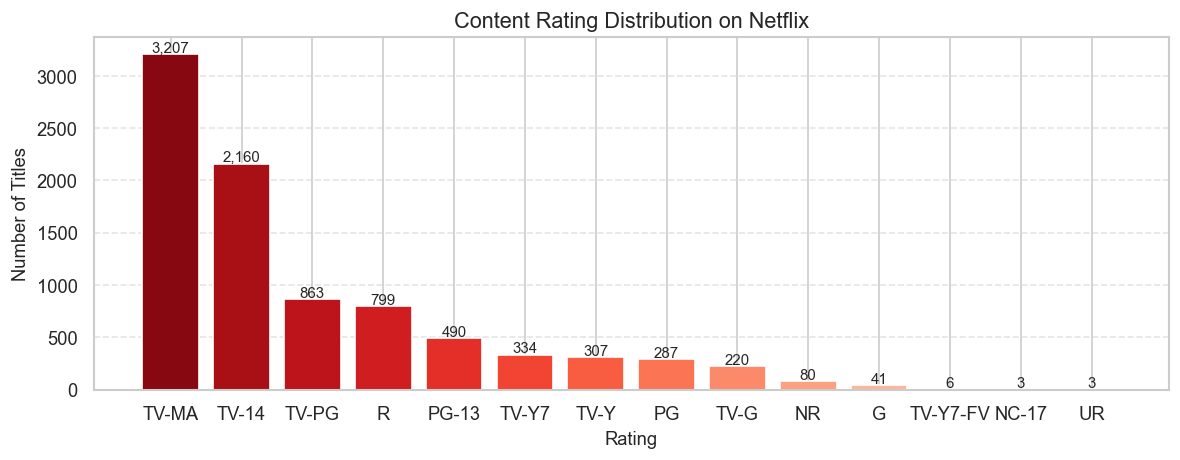

In [35]:
rating_counts = (
    df[df["rating"] != "Unknown"]["rating"]
    .value_counts()
)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(rating_counts.index, rating_counts.values,
              color=sns.color_palette("Reds_r", len(rating_counts)), edgecolor="white")
ax.set_title("Content Rating Distribution on Netflix")
ax.set_xlabel("Rating")
ax.set_ylabel("Number of Titles")
ax.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f"{int(bar.get_height()):,}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()




> **Insight:** **TV-MA** (Mature Audiences) is by far the most common rating, followed by **TV-14**.  
> This tells us Netflix primarily targets **adult audiences (18+)**, not families or children.  
> This is important context — Netflix is not competing directly with Disney+ on family content; it's competing on adult dramas, thrillers, and mature series.


### Question 6 — How long are Netflix movies typically?

Are Netflix movies getting longer or shorter? What's the typical runtime?


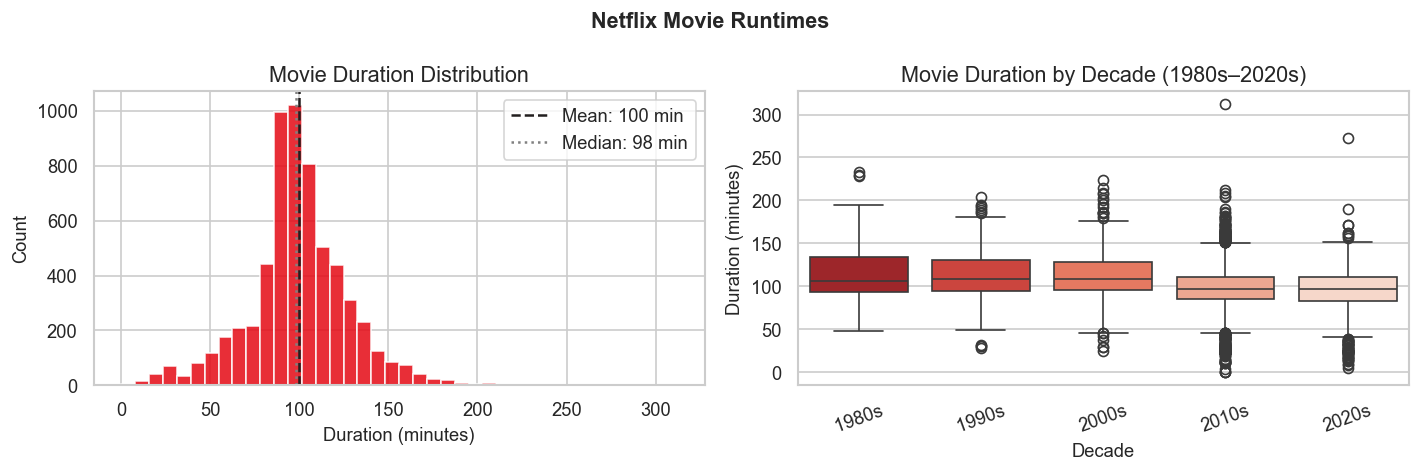

In [37]:
movie_durations = df[df["type"] == "Movie"]["duration_min"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(movie_durations, bins=40, color="#e50914", edgecolor="white", alpha=0.85)
axes[0].axvline(movie_durations.mean(), color="#221f1f", linestyle="--", linewidth=1.5,
                label=f"Mean: {movie_durations.mean():.0f} min")
axes[0].axvline(movie_durations.median(), color="gray", linestyle=":", linewidth=1.5,
                label=f"Median: {movie_durations.median():.0f} min")
axes[0].set_title("Movie Duration Distribution")
axes[0].set_xlabel("Duration (minutes)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Box plot by decade
df_movies = df[df["type"] == "Movie"].copy()
df_movies["decade"] = (df_movies["release_year"] // 10 * 10).astype(str) + "s"
decade_order = sorted(df_movies["decade"].dropna().unique())
decade_filter = [d for d in decade_order if int(d[:4]) >= 1980]

sns.boxplot(data=df_movies[df_movies["decade"].isin(decade_filter)],
            x="decade", y="duration_min",
            palette="Reds_r", ax=axes[1], order=decade_filter)
axes[1].set_title("Movie Duration by Decade (1980s–2020s)")
axes[1].set_xlabel("Decade")
axes[1].set_ylabel("Duration (minutes)")
axes[1].tick_params(axis="x", rotation=20)

plt.suptitle("Netflix Movie Runtimes", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


> **Insight:** The average Netflix movie runtime is approximately **90–100 minutes**, which aligns with traditional cinema standards.  
> The distribution is right-skewed — most movies fall in the 80–120 minute range, but a few run over 2.5 hours.  
> Movie durations have remained fairly consistent across decades, with the 2010s–2020s showing a slight compression in runtime.


---

## 5. Key Findings & Conclusions

Here's a summary of the most important insights from this analysis:

| # | Question | Key Finding |
|---|----------|-------------|
| 1 | Movies vs TV Shows | Movies dominate at ~69%, but TV Show additions are growing faster |
| 2 | Top countries | USA leads (2,818 titles), India is a strong #2 (972), South Korea is rising |
| 3 | Content growth | Netflix grew rapidly 2015–2019, peaked in 2019, COVID dipped 2020 |
| 4 | Top genres | International Movies, Dramas, and Comedies are the top 3 genres |
| 5 | Ratings | TV-MA dominates — Netflix is primarily an adult content platform |
| 6 | Movie duration | Typical Netflix movie is ~99 minutes, consistent across decades |

---

## 6. Business Implications

- 🌍 **Global strategy is working:** High international content suggests Netflix is successfully localising
- 📺 **TV shift:** The accelerating addition of TV Shows indicates Netflix is betting on series to reduce subscriber churn
- 🔞 **Adult-first:** The TV-MA dominance means Netflix's core value proposition is mature, prestige content — not family entertainment
- 🇮🇳 **India opportunity:** India's #2 position signals it's a priority growth market worth watching closely

---

## 7. Tools & Skills Demonstrated

- **Data Cleaning:** Null handling, dtype conversion, regex cleaning  
- **Exploratory Analysis:** Groupby, value_counts, describe, explode  
- **Visualization:** Matplotlib + Seaborn — bar, pie, histogram, box plot, line chart  
- **Storytelling:** Each chart paired with a business interpretation

---

*Dataset source: [Netflix Movies and TV Shows — Kaggle](https://www.kaggle.com/datasets/shivamb/netflix-shows)*
